# USD Rates RV v2 — Rolling PCA fly screener

Showcases the v2 RV toolkit additions on ~1y EOD SOFR data:
- **Rolling PCA residual** with eigenvector continuity (`rolling_residual`, `align_eigenvectors`)
- **Optimal OU bands** — Zeng-Lee 2014 (`optimal_ou_thresholds`)
- **OU S-score** — Avellaneda-Lee (`ou_sscore`)
- **ADF gate** (`adf_gate`)
- **Eigenportfolio returns** (`eigenportfolio_returns`)
- **Lead-lag** — Lévy area + cross-correlation (`levy_area`, `xcorr_lead_lag`)
- **Cost-aware screener** (`make_pca_fly_rv_screener`)

Mirrors `rv_pca_curve_fly.ipynb` plumbing.

In [7]:
%matplotlib inline
import sys; sys.path.append("../../")
import datetime, pytz, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (15, 6); plt.rcParams["axes.grid"] = True
from RVUtils.plt_timeseries import make_secondary_axis_plot

NYC = pytz.timezone("America/New_York")
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
ts = TimeseriesBuilder()
start = NYC.localize(datetime.datetime(2024, 7, 6, 17, 0))
end = NYC.localize(datetime.datetime(2026, 7, 6, 17, 0))
ROUTERS = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=True), "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=False)}

def load(queries):
    return ts.get_timeseries(start=start, end=end, queries=queries, n_jobs=12, routers=ROUTERS)

def sofr(tenors):
    df = load([UnifiedQuery(curve="USD-SOFR-1D", tenor=t, value=UnifiedValue.IRS_RATE) for t in tenors])
    return df.rename(columns={f"USD-SOFR-1D {t} OUTRIGHT RATE": t for t in tenors})[list(tenors)]

print("Setup OK. Window:", start.date(), "->", end.date())

DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb
DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


Setup OK. Window: 2024-07-06 -> 2026-07-06


In [8]:
# TENORS = ["1y", "1y1y", "2y1y", "3y1y", "4y1y", "5y1y", "6y1y", "7y1y", "8y1y", "9y1y", "10y2y", "12y3y", "15y5y", "20y5y", "25y5y"]
TENORS = [
	"IMM_1xIMM_5", 
	"IMM_5xIMM_9", 
	"IMM_9xIMM_13", 
	"IMM_13xIMM_17", 
	"IMM_17xIMM_21", 
	"IMM_21xIMM_25", 
	"IMM_25xIMM_29", 
	"IMM_29xIMM_33", 
	"IMM_33xIMM_37", 
	"IMM_37xIMM_41", 
	"IMM_41xIMM_45", 
	"IMM_45xIMM_49", 
	"IMM_49xIMM_53", 
	"IMM_53xIMM_57", 
	"IMM_57xIMM_61",
	"IMM_61xIMM_65",
	"IMM_65xIMM_69",
	"IMM_69xIMM_73",
	"IMM_73xIMM_77",
	"IMM_77xIMM_81",
	"IMM_81xIMM_85",
	"IMM_85xIMM_89",
	"IMM_89xIMM_93",
	"IMM_93xIMM_97",
	"IMM_97xIMM_101",
	"IMM_101xIMM_105",
	"IMM_105xIMM_109",
	"IMM_109xIMM_113",
	"IMM_113xIMM_117",
	"IMM_117xIMM_121",
	"IMM_121xIMM_125",
]
# TENORS = [
#     "IMM_2xIMM_6", 
#     "IMM_6xIMM_10", 
#     "IMM_10xIMM_14", 
#     "IMM_14xIMM_18", 
#     "IMM_18xIMM_22", 
#     "IMM_22xIMM_26", 
#     "IMM_26xIMM_30", 
#     "IMM_30xIMM_34", 
#     "IMM_34xIMM_38", 
#     "IMM_38xIMM_42", 
#     "IMM_42xIMM_46", 
#     "IMM_46xIMM_50", 
#     "IMM_50xIMM_54", 
#     "IMM_54xIMM_58", 
#     "IMM_58xIMM_62",
#     "IMM_62xIMM_66",
#     "IMM_66xIMM_70",
#     "IMM_70xIMM_74",
#     "IMM_74xIMM_78",
#     "IMM_78xIMM_82",
#     "IMM_82xIMM_86",
#     "IMM_86xIMM_90",
#     "IMM_90xIMM_94",
#     "IMM_94xIMM_98",
#     "IMM_98xIMM_102",
#     "IMM_102xIMM_106",
#     "IMM_106xIMM_110",
#     "IMM_110xIMM_114",
#     "IMM_114xIMM_118",
#     "IMM_118xIMM_122",
#     "IMM_122xIMM_126",
# ]
df_s = sofr(TENORS)
print(f"SOFR curve: {df_s.shape[0]} rows x {df_s.shape[1]} tenors")
df_s

SOFR curve: 498 rows x 31 tenors


,IMM_1xIMM_5,IMM_5xIMM_9,IMM_9xIMM_13,IMM_13xIMM_17,IMM_17xIMM_21,IMM_21xIMM_25,IMM_25xIMM_29,IMM_29xIMM_33,IMM_33xIMM_37,IMM_37xIMM_41,...,IMM_85xIMM_89,IMM_89xIMM_93,IMM_93xIMM_97,IMM_97xIMM_101,IMM_101xIMM_105,IMM_105xIMM_109,IMM_109xIMM_113,IMM_113xIMM_117,IMM_117xIMM_121,IMM_121xIMM_125
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-08,4.719635,3.840565,3.598652,3.543314,3.576707,3.641673,3.694551,3.733151,3.779721,3.835153,...,3.243404,3.146341,3.067154,3.005777,2.955539,2.897789,2.833290,2.760726,2.680116,2.592764
2024-07-09,4.730162,3.852793,3.619710,3.572565,3.619135,3.681813,3.731570,3.771132,3.820883,3.881110,...,3.286343,3.184669,3.100093,3.032553,2.976395,2.915402,2.850695,2.780893,2.706005,2.626654
2024-07-10,4.727536,3.845983,3.607188,3.554958,3.588818,3.654159,3.707826,3.746625,3.793460,3.849360,...,3.272386,3.175225,3.096279,3.035481,2.986031,2.928730,2.864300,2.791415,2.710095,2.621688
2024-07-11,4.601597,3.682984,3.482763,3.438517,3.492351,3.565997,3.628850,3.683478,3.739644,3.794876,...,3.222075,3.129604,3.056492,3.002674,2.960344,2.907443,2.844182,2.769318,2.682878,2.586906
2024-07-12,4.572804,3.647720,3.465653,3.444262,3.504340,3.570332,3.624235,3.672287,3.728392,3.791254,...,3.242881,3.147374,3.069670,3.009708,2.960878,2.904102,2.840003,2.767276,2.685940,2.597391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-29,4.041444,3.880794,3.751139,3.764848,3.847811,3.952238,4.053599,4.143180,4.233987,4.327609,...,4.198963,4.119645,4.046263,3.974843,3.907826,3.836836,3.761098,3.680622,3.595813,3.504684
2026-06-30,4.078083,3.918874,3.799169,3.809353,3.903489,3.999670,4.090287,4.174869,4.262607,4.354018,...,4.227352,4.143316,4.063687,3.984508,3.909936,3.834835,3.758845,3.681968,3.604701,3.524156
2026-07-01,4.096334,3.968971,3.851452,3.880517,3.959423,4.051080,4.150109,4.246261,4.338514,4.424892,...,4.280859,4.198127,4.121519,4.046919,3.977300,3.904763,3.828584,3.748774,3.665804,3.577264


## 1. Rolling PCA residual with eigenvector continuity (spec A)

Re-fits PCA on a trailing 261-day window at each step. `align_eigenvectors` flips sign of eigenvectors
across windows to prevent spurious jumps in the residual.

In [3]:
from RVUtils.pca_rv import rolling_residual, make_pca_rv_builder, eigenportfolio_returns

# Rolling PCA residual for outright 10y
resid_10y = rolling_residual(df_s, "10y", window=200, k=3, sign_align=True)
print(f"Rolling residual: {resid_10y.notna().sum()} observations")

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="matplotlib", title="10y SOFR: rolling PCA residual (200d window, k=3)"
)
plot(resid_10y.rename("10y rolling PCA residual") * 100, which="left")
z = (resid_10y - resid_10y.rolling(65).mean()) / resid_10y.rolling(65).std()
plot(z.rename("z-score (65d)"), which="right",
     indicators=[{"kind": "zbands", "entry": 2, "stop": 3}])
legend(show_date=True, loc="upper left")
plt.show()

KeyError: '10y'

PCA-neutral 2s5s10s weights: {'2y': -0.403, '5y': 1.0, '10y': -0.652}


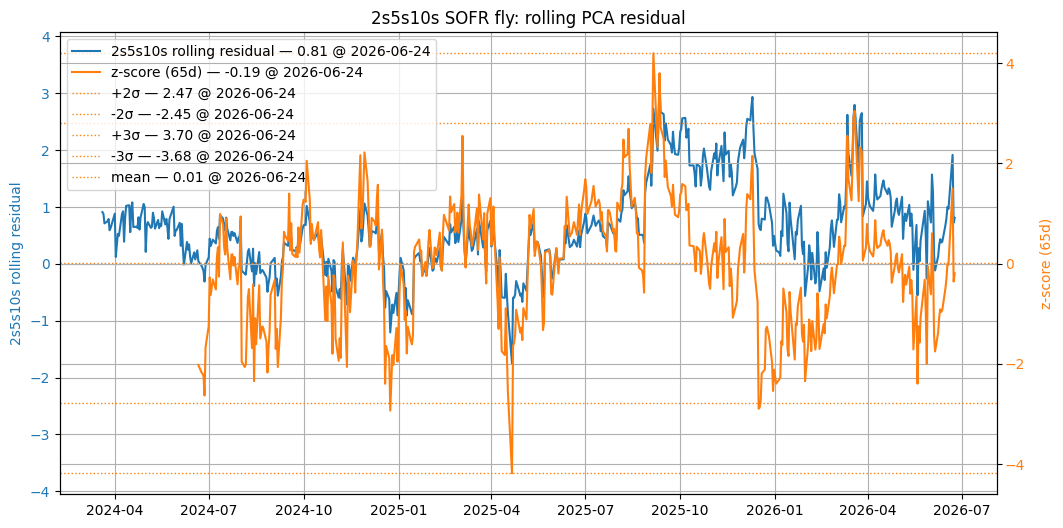

In [15]:
# Rolling PCA residual for 2s5s10s fly
fit_fn, fv_fn, res_fn, fly_w_fn, *_ = make_pca_rv_builder(df_s, on="levels", n_factors=3, sort_by_tenor=False)
fit_fn()
w_2s5s10s = fly_w_fn("2y", "5y", "10y")
print("PCA-neutral 2s5s10s weights:", {k: round(v, 3) for k, v in w_2s5s10s.items()})

resid_fly = rolling_residual(df_s, ["2y", "5y", "10y"], weights=w_2s5s10s, window=200, k=3)

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="matplotlib", title="2s5s10s SOFR fly: rolling PCA residual"
)
plot(resid_fly.rename("2s5s10s rolling residual") * 100, which="left")
z_fly = (resid_fly - resid_fly.rolling(65).mean()) / resid_fly.rolling(65).std()
plot(z_fly.rename("z-score (65d)"), which="right",
     indicators=[{"kind": "zbands", "entry": 2, "stop": 3}])
legend(show_date=True, loc="upper left")
plt.show()

## 2. OU calibration + optimal entry/exit bands (spec B)

Calibrate OU on the rolling residual, then compute Zeng-Lee optimal thresholds.

In [16]:
from RVUtils.mean_reversion import calibrate_ou, optimal_ou_thresholds, ou_sscore, adf_gate

# OU calibration on 2s5s10s rolling residual
ou = calibrate_ou(resid_fly)
print("OU calibration (2s5s10s rolling residual):")
for k in ["mu", "kappa", "sigma", "half_life"]:
    print(f"  {k}: {ou[k]:.4f}")

# Optimal thresholds (in sigma_eq units)
from RVUtils.cost_model import structure_cost_bps
cost_bp = structure_cost_bps([2, 5, 10], [abs(w_2s5s10s["2y"]), abs(w_2s5s10s["5y"]), abs(w_2s5s10s["10y"])])
sigma_eq = ou["sigma"] / np.sqrt(2 * ou["kappa"]) if ou["kappa"] > 0 else np.nan
cost_sigma = (cost_bp / 10000) / sigma_eq if np.isfinite(sigma_eq) and sigma_eq > 0 else 0.0

a_sym, b_sym = optimal_ou_thresholds(ou["kappa"], ou["sigma"], cost=cost_sigma, case="symmetric")
a_lo, b_lo = optimal_ou_thresholds(ou["kappa"], ou["sigma"], cost=cost_sigma, case="long_only")
print(f"\nStructure cost: {cost_bp:.2f} bp -> {cost_sigma:.4f} sigma_eq units")
print(f"Optimal symmetric bands: entry ±{a_sym:.3f}σ, exit ±{-b_sym:.3f}σ")
print(f"Optimal long-only bands: entry {a_lo:.3f}σ, exit {b_lo:.3f}σ")

OU calibration (2s5s10s rolling residual):
  mu: 0.0063
  kappa: 0.1117
  sigma: 0.0037
  half_life: 6.2065

Structure cost: 1.13 bp -> 0.0145 sigma_eq units
Optimal symmetric bands: entry ±0.025σ, exit ±0.025σ
Optimal long-only bands: entry 0.049σ, exit 0.000σ


## 3. OU S-score + ADF gate (spec D, E)

S-score standardizes the residual by the OU equilibrium volatility. ADF gate filters non-stationary residuals.

In [17]:
# S-score on multiple fly residuals
flies = {
    "2s5s10s": (["2y", "5y", "10y"], w_2s5s10s),
    "5s10s30s": (["5y", "10y", "30y"], fly_w_fn("5y", "10y", "30y")),
    "2s10s30s": (["2y", "10y", "30y"], fly_w_fn("2y", "10y", "30y")),
    "3s7s20s": (["3y", "7y", "20y"], fly_w_fn("3y", "7y", "20y")),
}

rows = []
for name, (legs, wts) in flies.items():
    resid = rolling_residual(df_s, legs, weights=wts, window=200, k=3)
    if resid.notna().sum() < 30:
        continue
    sscore = ou_sscore(resid)
    adf_ok = adf_gate(resid, pval=0.10)
    ou_p = calibrate_ou(resid)
    rows.append({
        "fly": name,
        "s_score": round(float(sscore.iloc[-1]), 3) if sscore.notna().sum() > 0 else np.nan,
        "adf_pass": adf_ok,
        "half_life": round(ou_p["half_life"], 1),
        "kappa": round(ou_p["kappa"], 4),
        "weights": {k: round(v, 3) for k, v in wts.items()},
    })

df_sscore = pd.DataFrame(rows).set_index("fly")
print("S-score + ADF gate for SOFR flies (rolling PCA residual):")
df_sscore

S-score + ADF gate for SOFR flies (rolling PCA residual):


,s_score,adf_pass,half_life,kappa,weights
fly,,,,,
2s5s10s,0.232,True,6.2,0.1117,"{'2y': -0.403, '5y': 1.0, '10y': -0.652}"
5s10s30s,-0.139,True,5.2,0.1329,"{'5y': -0.56, '10y': 1.0, '30y': -0.467}"
2s10s30s,-0.053,True,4.7,0.1481,"{'2y': -0.355, '10y': 1.0, '30y': -0.735}"
3s7s20s,0.630,True,5.9,0.1169,"{'3y': -0.514, '7y': 1.0, '20y': -0.542}"


## 4. Eigenportfolio returns (spec F)

Factor-mimicking portfolio returns: `F_j(t) = Σ_i (v_ji / σ_i) R_i(t)`.

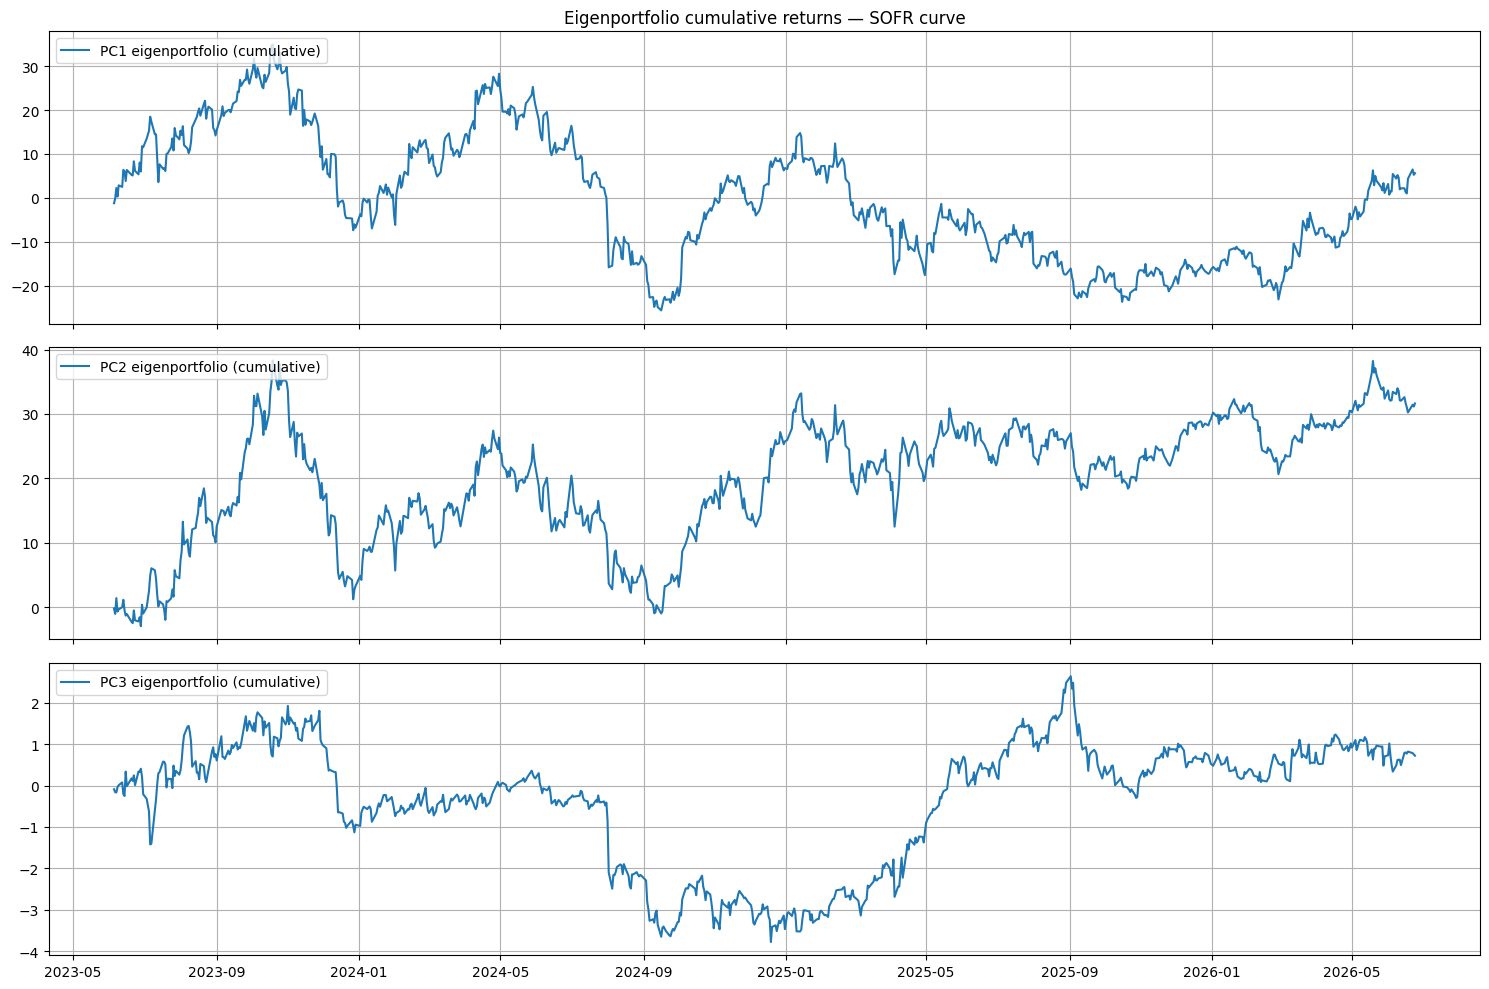

Eigenportfolio return correlation matrix:


,PC1,PC2,PC3
PC1,1.000,0.823,0.033
PC2,0.823,1.000,0.205
PC3,0.033,0.205,1.000


In [18]:
_, get_model_fn = make_pca_rv_builder(df_s, on="levels", n_factors=3, sort_by_tenor=False)[-2:]
# re-fit to get the model
fit2, *_, get_model2 = make_pca_rv_builder(df_s, on="levels", n_factors=3, sort_by_tenor=False)
fit2()
model, _ = get_model2()

asset_returns = df_s.diff().dropna()
asset_vols = asset_returns.std()
F = eigenportfolio_returns(model.loadings[["PC1", "PC2", "PC3"]], asset_returns, asset_vols)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for i, pc in enumerate(["PC1", "PC2", "PC3"]):
    axes[i].plot(F[pc].cumsum(), label=f"{pc} eigenportfolio (cumulative)")
    axes[i].legend(loc="upper left")
    axes[i].grid(True)
axes[0].set_title("Eigenportfolio cumulative returns — SOFR curve")
plt.tight_layout()
plt.show()

print("Eigenportfolio return correlation matrix:")
F.corr().round(3)

## 5. Lead-lag — Lévy area, signal, cross-correlation, Granger (spec C)

Which leg leads informs execution timing and hedging variable choice.

5y vs 10y cross-corr lead-lag: lag=0 (positive => 5y leads), corr=0.9628
2y vs 30y cross-corr lead-lag: lag=0, corr=0.6653

Granger causality (5y -> 10y): best lag=3, p-value=0.2219
Granger causality (10y -> 5y): best lag=1, p-value=0.0154

Lévy area signal: 177 long, 80 short, 506 flat periods


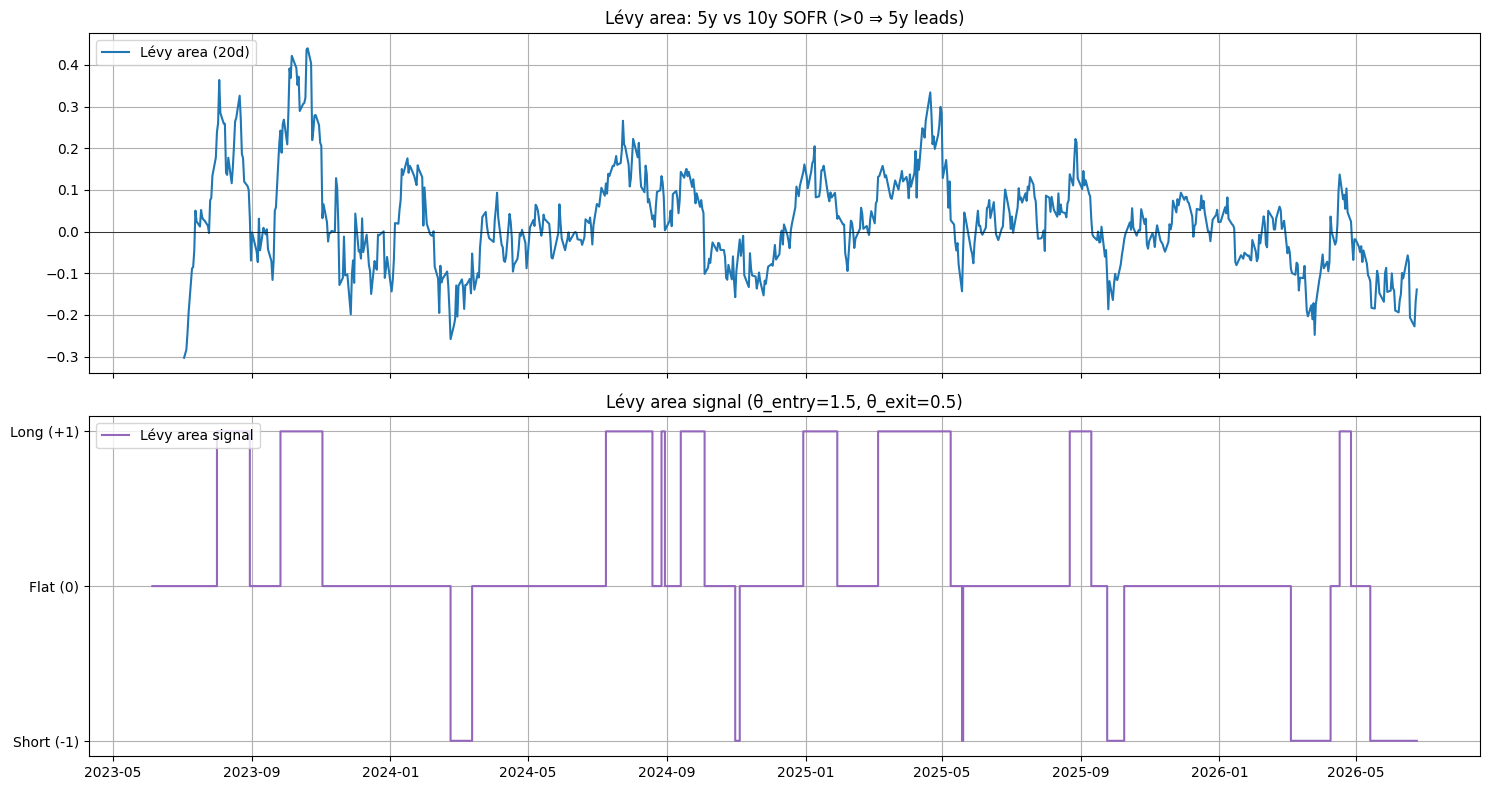

In [19]:
from RVUtils.lead_lag import levy_area, levy_area_signal, xcorr_lead_lag, granger_lead_lag

# Cross-correlation lead-lag
ll = xcorr_lead_lag(df_s["5y"], df_s["10y"], max_lag=5)
print(f"5y vs 10y cross-corr lead-lag: lag={ll['lag']} (positive => 5y leads), corr={ll['corr']:.4f}")

ll2 = xcorr_lead_lag(df_s["2y"], df_s["30y"], max_lag=5)
print(f"2y vs 30y cross-corr lead-lag: lag={ll2['lag']}, corr={ll2['corr']:.4f}")

# Granger causality
gr = granger_lead_lag(df_s["5y"], df_s["10y"], max_lag=5)
print(f"\nGranger causality (5y -> 10y): best lag={gr['lag']}, p-value={gr['pvalue']:.4f}")
gr2 = granger_lead_lag(df_s["10y"], df_s["5y"], max_lag=5)
print(f"Granger causality (10y -> 5y): best lag={gr2['lag']}, p-value={gr2['pvalue']:.4f}")

# Lévy area
la = levy_area(df_s["5y"], df_s["10y"], window=20)

# Lévy area signal (entry/exit with persistence)
la_sig = levy_area_signal(df_s["5y"], df_s["10y"], window=20, theta_entry=1.5, theta_exit=0.5)
print(f"\nLévy area signal: {(la_sig == 1).sum()} long, {(la_sig == -1).sum()} short, {(la_sig == 0).sum()} flat periods")

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].plot(la.index, la.values, label="Lévy area (20d)")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("Lévy area: 5y vs 10y SOFR (>0 ⇒ 5y leads)")
axes[0].legend(loc="upper left")
axes[0].grid(True)

axes[1].plot(la_sig.index, la_sig.values, label="Lévy area signal", color="tab:purple", drawstyle="steps-post")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["Short (-1)", "Flat (0)", "Long (+1)"])
axes[1].set_title("Lévy area signal (θ_entry=1.5, θ_exit=0.5)")
axes[1].legend(loc="upper left")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Cost-aware fly screener — `make_pca_fly_rv_screener` (spec G, H, J)

End-to-end *Catching the Butterfly* pipeline: rolling PCA residual → ADF gate → OU half-life → cost-aware composite ranking.

Runs the screener twice — without cost adjustments and with `cost_z` + `lambda_carry` — to show how transaction costs and carry reshape the ranking.

In [20]:
from RVUtils.screener_rv import make_pca_fly_rv_screener
from RVUtils.cost_model import transaction_cost_bps, structure_cost_bps

structures = {
    "2s5s10s": ("2y", "5y", "10y"),
    "2s5s30s": ("2y", "5y", "30y"),
    "2s10s30s": ("2y", "10y", "30y"),
    "3s5s10s": ("3y", "5y", "10y"),
    "3s7s10s": ("3y", "7y", "10y"),
    "3s7s20s": ("3y", "7y", "20y"),
    "5s7s10s": ("5y", "7y", "10y"),
    "5s10s30s": ("5y", "10y", "30y"),
    "7s10s30s": ("7y", "10y", "30y"),
    "7s20s30s": ("7y", "20y", "30y"),
}

# PCA-neutral weights for each fly
weights_map = {}
for name, (s, b, l) in structures.items():
    try:
        w = fly_w_fn(s, b, l)
        weights_map[name] = w
    except Exception as e:
        print(f"Skipping {name}: {e}")

# --- Cost model demo ---
tenor_map = {"2y": 2, "3y": 3, "5y": 5, "7y": 7, "10y": 10, "20y": 20, "30y": 30}
print("Transaction cost model (bid-ask half-spread, bp):")
for t in ["2y", "5y", "10y", "20y", "30y"]:
    print(f"  {t}: {transaction_cost_bps(tenor_map[t]):.2f} bp")

print("\nStructure costs:")
for name, (s, b, l) in list(structures.items())[:4]:
    wts = weights_map.get(name, {})
    if wts:
        legs = [tenor_map[s], tenor_map[b], tenor_map[l]]
        ws = [abs(wts[s]), abs(wts[b]), abs(wts[l])]
        c = structure_cost_bps(legs, ws)
        print(f"  {name}: {c:.2f} bp")

# --- Screener: no cost adjustment (baseline) ---
result_nocost = make_pca_fly_rv_screener(
    df_s, structures, weights_map,
    window=200, k=3, cost_z=0.0, lambda_carry=0.0, adf_pval=0.10,
)

# --- Screener: with cost deduction ---
result_cost = make_pca_fly_rv_screener(
    df_s, structures, weights_map,
    window=200, k=3, cost_z=0.02, lambda_carry=0.0, adf_pval=0.10,
)

print(f"\n--- Baseline (no cost) ---")
print(result_nocost[["zscore", "half_life", "adf_pass", "composite", "direction"]].to_string(float_format="{:.3f}".format))

print(f"\n--- With cost_z=0.02 deduction ---")
print(result_cost[["zscore", "half_life", "adf_pass", "composite", "direction"]].to_string(float_format="{:.3f}".format))

# Show the composite shift
comparison = pd.DataFrame({
    "composite_baseline": result_nocost["composite"],
    "composite_with_cost": result_cost["composite"].reindex(result_nocost.index),
    "delta": result_cost["composite"].reindex(result_nocost.index).abs() - result_nocost["composite"].abs(),
})
print(f"\nCost impact on |composite| (negative = cost hurts ranking):")
print(comparison.to_string(float_format="{:.4f}".format))

Transaction cost model (bid-ask half-spread, bp):
  2y: 0.35 bp
  5y: 0.50 bp
  10y: 0.75 bp
  20y: 1.25 bp
  30y: 1.75 bp

Structure costs:
  2s5s10s: 1.13 bp
  2s5s30s: 1.56 bp
  2s10s30s: 2.16 bp
  3s5s10s: 1.08 bp

--- Baseline (no cost) ---
           zscore  half_life  adf_pass  composite direction
structure                                                  
3s7s20s     1.943      5.930      True      0.381      SELL
3s5s10s     1.105      3.510      True      0.303      SELL
2s5s30s     1.184      8.761     False      0.299      SELL
5s7s10s    -0.561      1.627      True     -0.252       BUY
2s10s30s    0.607      4.681      True      0.250      SELL
7s10s30s    0.537      4.088      True      0.245      SELL
5s10s30s    0.469      5.217      True      0.235      SELL
7s20s30s   -0.172      2.739      True     -0.211       BUY
3s7s10s     0.167      2.530      True      0.211      SELL
2s5s10s    -0.195      6.207      True     -0.206       BUY

--- With cost_z=0.02 deduction --

## 7. Deep dive — top-ranked fly

Rolling residual, S-score with Zeng-Lee optimal OU bands, and OU forecast for the top-ranked structure.

Top fly: 3s7s20s  weights: {3y: -0.514, 7y: 1.000, 20y: -0.542}
  direction: SELL  z: 1.94  hl: 5.9d  adf: True
  OU forecast (6d): current=-0.05bp -> E[x]=-0.23bp ± 0.51bp
  Zeng-Lee optimal bands: entry ±0.042σ_eq, exit ±0.042σ_eq (cost=1.48bp = 0.0249σ_eq)


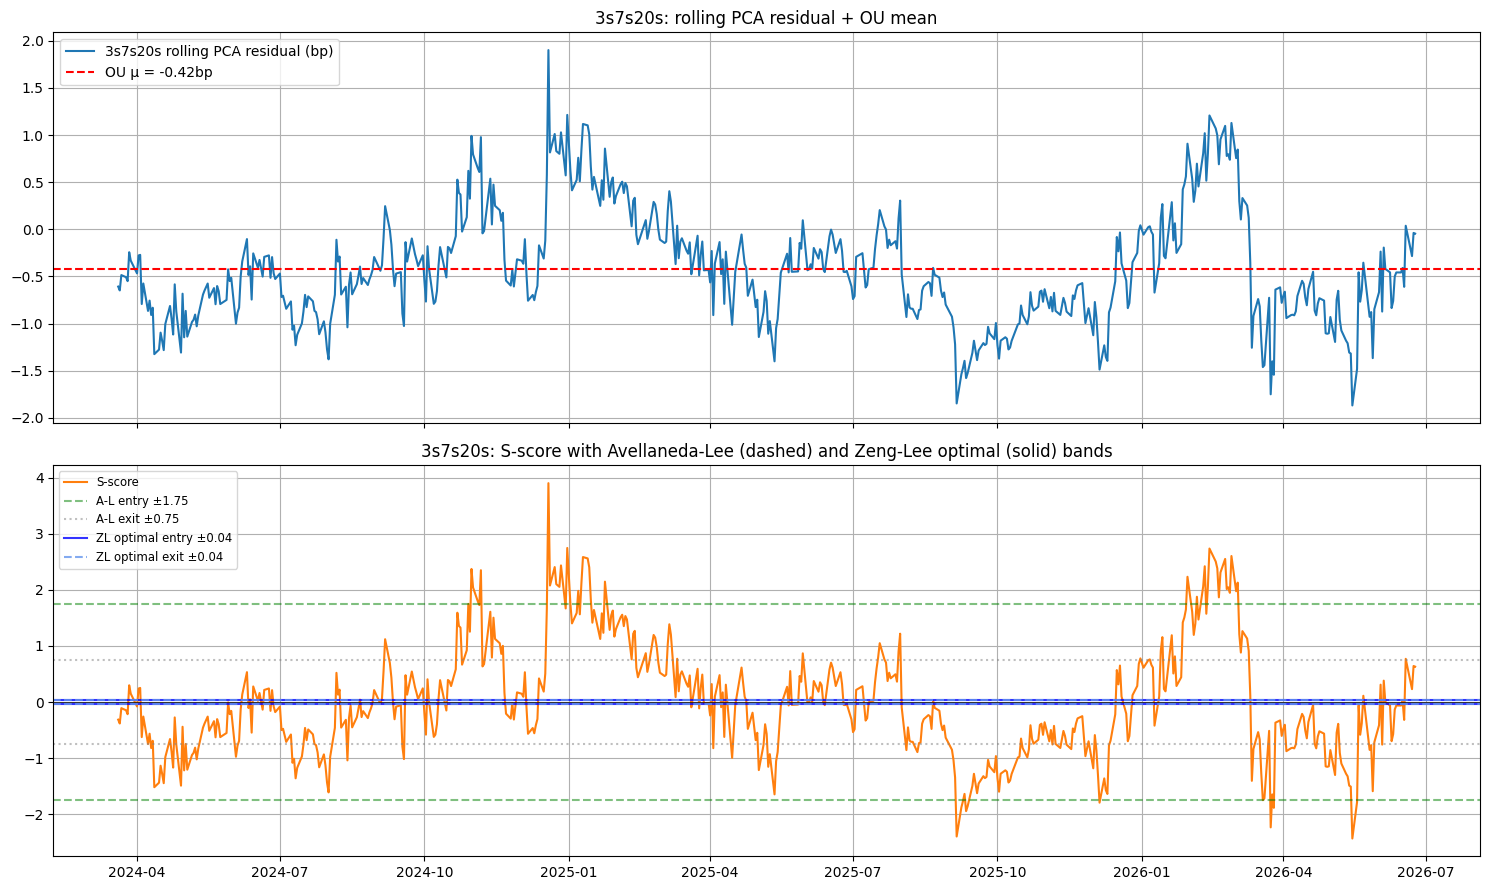

In [21]:
from RVUtils.mean_reversion import ou_conditional

result = result_nocost  # use baseline for deep dive
top_name = result.index[0]
top_legs = list(structures[top_name])
top_wts = weights_map[top_name]
print(f"Top fly: {top_name}  weights: {{{', '.join(f'{k}: {v:.3f}' for k, v in top_wts.items())}}}")
print(f"  direction: {result.loc[top_name, 'direction']}  z: {result.loc[top_name, 'zscore']:.2f}  hl: {result.loc[top_name, 'half_life']:.1f}d  adf: {result.loc[top_name, 'adf_pass']}")

top_resid = rolling_residual(df_s, top_legs, weights=top_wts, window=200, k=3)
top_ou = calibrate_ou(top_resid)
top_sscore = ou_sscore(top_resid)

# OU conditional forecast
x0 = float(top_resid.iloc[-1])
cond = ou_conditional(x0, top_ou, horizon=top_ou["half_life"])
print(f"  OU forecast ({top_ou['half_life']:.0f}d): current={x0*100:.2f}bp -> E[x]={cond['mean']*100:.2f}bp ± {cond['std']*100:.2f}bp")

# Optimal OU bands for this fly
top_legs_tenors = [tenor_map[l] for l in top_legs]
top_legs_abs_w = [abs(top_wts[l]) for l in top_legs]
top_cost_bp = structure_cost_bps(top_legs_tenors, top_legs_abs_w)
top_sigma_eq = top_ou["sigma"] / np.sqrt(2 * top_ou["kappa"]) if top_ou["kappa"] > 0 else np.nan
top_cost_sigma = (top_cost_bp / 10000) / top_sigma_eq if np.isfinite(top_sigma_eq) and top_sigma_eq > 0 else 0.0

a_opt, b_opt = optimal_ou_thresholds(top_ou["kappa"], top_ou["sigma"], cost=top_cost_sigma, case="symmetric")
print(f"  Zeng-Lee optimal bands: entry ±{a_opt:.3f}σ_eq, exit ±{-b_opt:.3f}σ_eq (cost={top_cost_bp:.2f}bp = {top_cost_sigma:.4f}σ_eq)")

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(top_resid.index, top_resid.values * 100, label=f"{top_name} rolling PCA residual (bp)")
axes[0].axhline(top_ou["mu"] * 100, color="red", ls="--", label=f"OU μ = {top_ou['mu']*100:.2f}bp")
axes[0].legend(loc="upper left")
axes[0].grid(True)
axes[0].set_title(f"{top_name}: rolling PCA residual + OU mean")

axes[1].plot(top_sscore.index, top_sscore.values, label="S-score", color="tab:orange")

# Avellaneda-Lee fixed thresholds
axes[1].axhline(1.75, color="green", ls="--", alpha=0.5, label="A-L entry ±1.75")
axes[1].axhline(-1.75, color="green", ls="--", alpha=0.5)
axes[1].axhline(0.75, color="gray", ls=":", alpha=0.5, label="A-L exit ±0.75")
axes[1].axhline(-0.75, color="gray", ls=":", alpha=0.5)

# Zeng-Lee optimal bands (in S-score units — a_opt is in sigma_eq, S-score IS in sigma_eq)
axes[1].axhline(a_opt, color="blue", ls="-", lw=1.5, alpha=0.8, label=f"ZL optimal entry ±{a_opt:.2f}")
axes[1].axhline(-a_opt, color="blue", ls="-", lw=1.5, alpha=0.8)
axes[1].axhline(-b_opt, color="cornflowerblue", ls="--", lw=1.5, alpha=0.8, label=f"ZL optimal exit ±{-b_opt:.2f}")
axes[1].axhline(b_opt, color="cornflowerblue", ls="--", lw=1.5, alpha=0.8)

axes[1].axhline(0, color="black", lw=0.5)
axes[1].legend(loc="upper left", fontsize="small")
axes[1].grid(True)
axes[1].set_title(f"{top_name}: S-score with Avellaneda-Lee (dashed) and Zeng-Lee optimal (solid) bands")

plt.tight_layout()
plt.show()

## 8. OLS sub-period beta stability (spec I)

Check whether the PCA fly's beta to level/slope has been stable across regimes.

In [22]:
from RVUtils.regression import ols_segment

# Build a fly timeseries and regress on level (PC1 score) and slope (PC2 score)
_, scores = get_model2()
fly_ts = sum(top_wts[c] * df_s[c] for c in top_legs).dropna()
fly_ts.name = top_name

common = fly_ts.index.intersection(scores.index)
mid = common[len(common) // 2]
periods = [(common[0], mid), (mid, common[-1])]

seg = ols_segment(
    fly_ts.loc[common],
    scores[["PC1", "PC2"]].loc[common],
    periods,
)

print(f"Beta stability for {top_name} vs PC1/PC2:")
for s in seg:
    p0, p1 = pd.Timestamp(s["period"][0]), pd.Timestamp(s["period"][1])
    print(f"  {p0.date()} -> {p1.date()}: "
          f"β_PC1={s['betas']['PC1']:.4f}, β_PC2={s['betas']['PC2']:.4f}, "
          f"adj-R²={s['adj_r2']:.3f} (n={s['nobs']})")

Beta stability for 3s7s20s vs PC1/PC2:
  2023-06-02 -> 2024-12-12: β_PC1=-0.0552, β_PC2=0.0711, adj-R²=0.764 (n=383)
  2024-12-12 -> 2026-06-24: β_PC1=0.0847, β_PC2=-0.1265, adj-R²=0.712 (n=382)


## 9. PCA Screener — per-tenor residuals, fly scan, curve scan

CS "PCA Unleashed" / JPM "RV on EUR swap yield curve" / ING "Deconstructing the EUR yield curve" style
screener: identify current mispricings across the entire tenor set, then rank all fly and curve combinations
by PCA-neutral dislocation.

In [9]:
from RVUtils.pca_rv import screen_residuals, screen_flies, screen_curves

# --- 9a. Per-tenor PCA residual snapshot ---
# Positive residual => actual above PCA fair value => tenor is CHEAP (for yields)
# Negative residual => RICH
sr = screen_residuals(df_s, on="levels", n_factors=3, zscore_window=60, pctl_window=200)
print("=== Per-Tenor PCA Residual Snapshot ===")
print(f"Date: {df_s.index[-1].strftime('%Y-%m-%d')}\n")
display(sr.style.format({
    "actual": "{:.4f}", "fitted": "{:.4f}", "residual": "{:.4f}",
    "zscore": "{:+.2f}", "percentile": "{:.0%}",
    "residual_1d": "{:.4f}", "residual_1w": "{:.4f}", "residual_1m": "{:.4f}",
}).background_gradient(subset=["zscore"], cmap="RdYlGn", vmin=-3, vmax=3))

# --- 9b. Fly screener: all 3-leg combos, PC1+PC2 neutral ---
sf = screen_flies(df_s, on="levels", n_factors=3, zscore_window=60, pctl_window=200, top_n=15)
print("\n=== Top Dislocated PCA-Neutral Flies ===")
print("Positive zscore => belly CHEAP, negative => belly RICH\n")
display(sf.style.format({
    "w_short": "{:.3f}", "w_long": "{:.3f}", "spread": "{:.4f}",
    "residual": "{:+.4f}", "zscore": "{:+.2f}", "percentile": "{:.0%}",
    "mean": "{:.4f}", "std": "{:.4f}",
}).background_gradient(subset=["zscore"], cmap="RdYlGn", vmin=-3, vmax=3))

# --- 9c. Curve screener: all 2-leg combos, PC1 neutral ---
sc = screen_curves(df_s, on="levels", n_factors=3, zscore_window=60, pctl_window=200, top_n=15)
print("\n=== Top Dislocated PC1-Neutral Curves ===")
print("Positive zscore => steepener cheap, negative => flattener cheap\n")
display(sc.style.format({
    "w_short": "{:.3f}", "spread": "{:.4f}",
    "residual": "{:+.4f}", "zscore": "{:+.2f}", "percentile": "{:.0%}",
    "mean": "{:.4f}", "std": "{:.4f}",
}).background_gradient(subset=["zscore"], cmap="RdYlGn", vmin=-3, vmax=3))

=== Per-Tenor PCA Residual Snapshot ===
Date: 2026-07-06



,actual,fitted,residual,zscore,percentile,residual_1d,residual_1w,residual_1m
tenor,,,,,,,,
IMM_1xIMM_5,4.0348,4.0851,-0.0503,+0.77,66%,0.0113,-0.0721,-0.1767
IMM_5xIMM_9,3.9239,3.9186,0.0053,-1.31,20%,0.0303,0.0141,0.0823
IMM_9xIMM_13,3.8345,3.8022,0.0323,+0.07,49%,0.0036,0.0375,0.0726
IMM_13xIMM_17,3.8739,3.8349,0.0389,+1.03,80%,-0.0047,0.0383,0.0430
IMM_17xIMM_21,3.9464,3.9369,0.0095,+0.17,55%,-0.0173,0.0128,0.0211
IMM_21xIMM_25,4.0598,4.0664,-0.0065,-0.21,47%,-0.0367,0.0066,-0.0133
IMM_25xIMM_29,4.1673,4.1768,-0.0095,-0.05,54%,-0.0392,-0.0004,-0.0332
IMM_29xIMM_33,4.2510,4.2660,-0.0150,-0.10,50%,-0.0312,-0.0211,-0.0325
IMM_33xIMM_37,4.3386,4.3563,-0.0177,+0.00,55%,-0.0211,-0.0278,-0.0309



=== Top Dislocated PCA-Neutral Flies ===
Positive zscore => belly CHEAP, negative => belly RICH



,short,body,long,w_short,w_long,spread,residual,zscore,percentile,mean,std
0,IMM_53xIMM_57,IMM_61xIMM_65,IMM_121xIMM_125,-0.837,-0.178,0.1327,+0.0116,+2.16,100%,0.1211,0.0054
1,IMM_1xIMM_5,IMM_37xIMM_41,IMM_57xIMM_61,-0.217,-0.861,-0.5137,-0.0463,-2.07,2%,-0.4673,0.0223
2,IMM_1xIMM_5,IMM_37xIMM_41,IMM_61xIMM_65,-0.243,-0.859,-0.6016,-0.0576,-2.04,2%,-0.5441,0.0282
3,IMM_1xIMM_5,IMM_37xIMM_41,IMM_53xIMM_57,-0.196,-0.870,-0.4641,-0.0367,-2.03,2%,-0.4274,0.0181
4,IMM_1xIMM_5,IMM_21xIMM_25,IMM_25xIMM_29,-0.181,-0.970,-0.7143,-0.0264,-2.02,2%,-0.6878,0.0131
5,IMM_1xIMM_5,IMM_37xIMM_41,IMM_65xIMM_69,-0.267,-0.855,-0.6598,-0.0661,-1.97,2%,-0.5937,0.0335
6,IMM_1xIMM_5,IMM_37xIMM_41,IMM_49xIMM_53,-0.169,-0.897,-0.4486,-0.0318,-1.96,2%,-0.4168,0.0162
7,IMM_1xIMM_5,IMM_41xIMM_45,IMM_45xIMM_49,-0.056,-0.963,-0.1354,-0.0100,-1.95,2%,-0.1255,0.0051
8,IMM_1xIMM_5,IMM_33xIMM_37,IMM_57xIMM_61,-0.312,-0.840,-0.8982,-0.0605,-1.94,2%,-0.8376,0.0311
9,IMM_53xIMM_57,IMM_57xIMM_61,IMM_121xIMM_125,-0.933,-0.079,0.0455,+0.0056,+1.92,100%,0.0399,0.0029



=== Top Dislocated PC1-Neutral Curves ===
Positive zscore => steepener cheap, negative => flattener cheap



,short,long,w_short,spread,residual,zscore,percentile,mean,std
0,IMM_53xIMM_57,IMM_57xIMM_61,-1.022,-0.0904,+0.0071,+1.68,94%,-0.0975,0.0043
1,IMM_53xIMM_57,IMM_61xIMM_65,-1.038,-0.1738,+0.0151,+1.54,92%,-0.1889,0.0098
2,IMM_53xIMM_57,IMM_65xIMM_69,-1.055,-0.2827,+0.0203,+1.41,90%,-0.3030,0.0144
3,IMM_49xIMM_53,IMM_65xIMM_69,-1.103,-0.4718,+0.0205,+1.39,88%,-0.4923,0.0148
4,IMM_49xIMM_53,IMM_69xIMM_73,-1.127,-0.6261,+0.0244,+1.38,88%,-0.6504,0.0176
5,IMM_53xIMM_57,IMM_69xIMM_73,-1.077,-0.4330,+0.0241,+1.32,88%,-0.4571,0.0183
6,IMM_1xIMM_5,IMM_101xIMM_105,2.606,14.5182,+0.4705,+1.26,96%,14.0477,0.3726
7,IMM_49xIMM_53,IMM_61xIMM_65,-1.085,-0.3598,+0.0154,+1.26,87%,-0.3752,0.0122
8,IMM_1xIMM_5,IMM_97xIMM_101,2.664,14.8240,+0.4723,+1.26,96%,14.3517,0.3758
9,IMM_1xIMM_5,IMM_105xIMM_109,2.562,14.2673,+0.4671,+1.26,97%,13.8001,0.3717


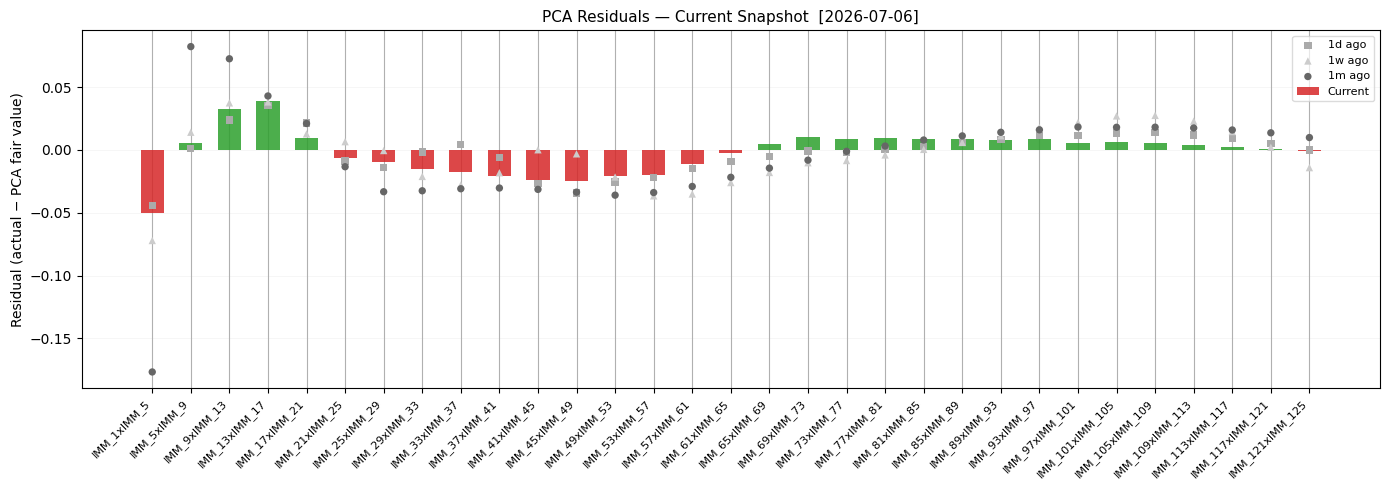

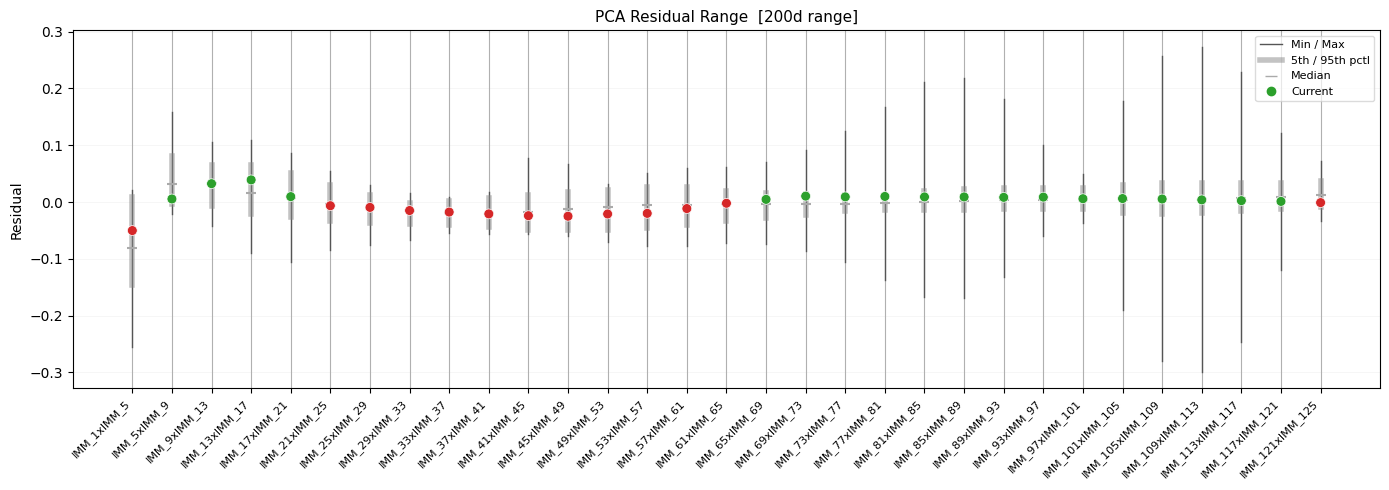

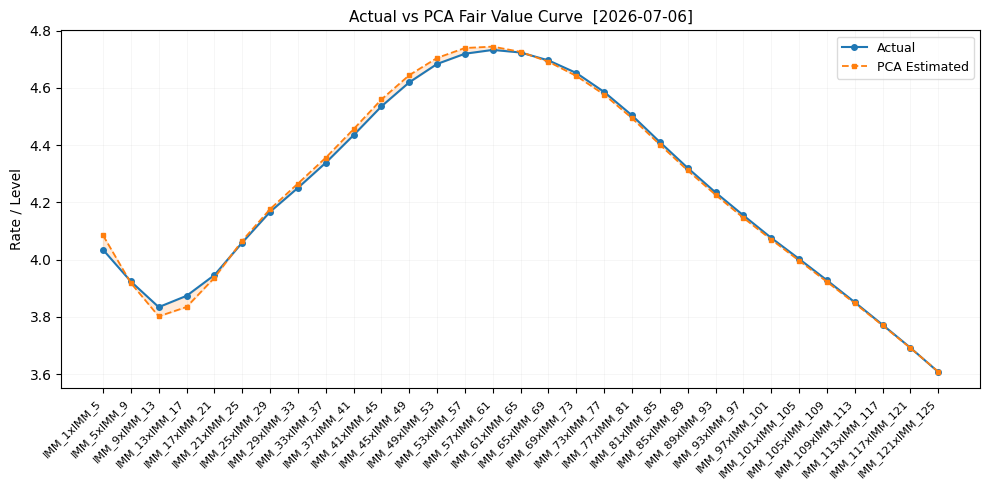

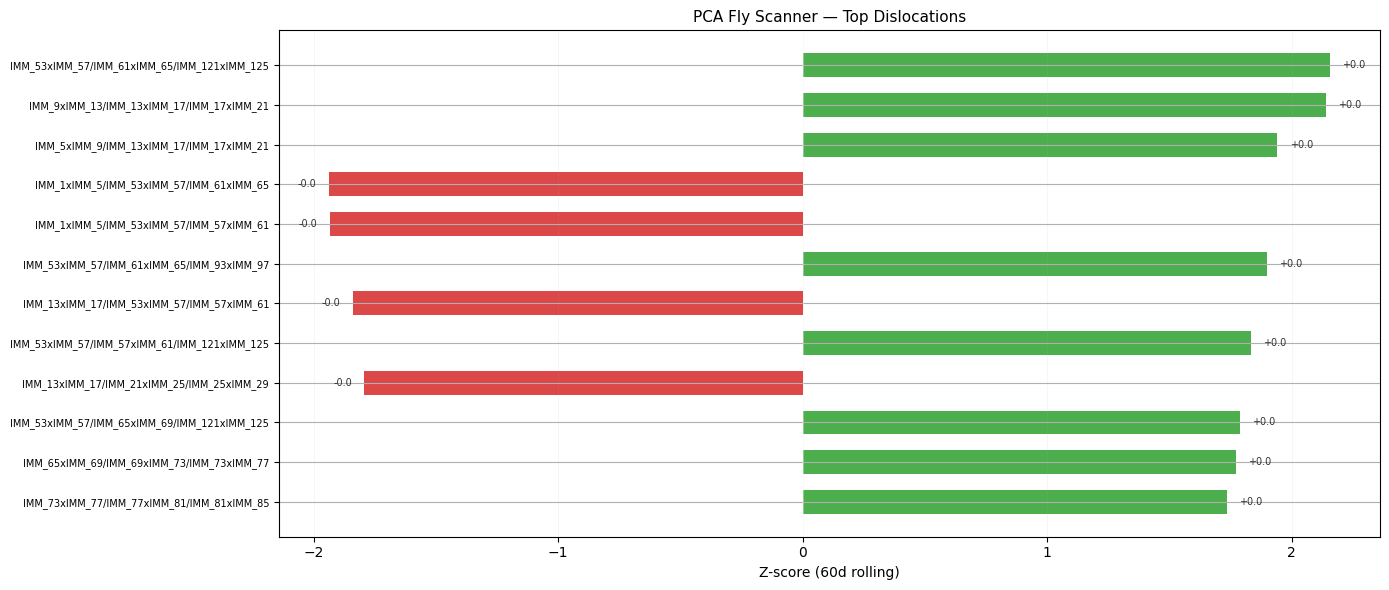

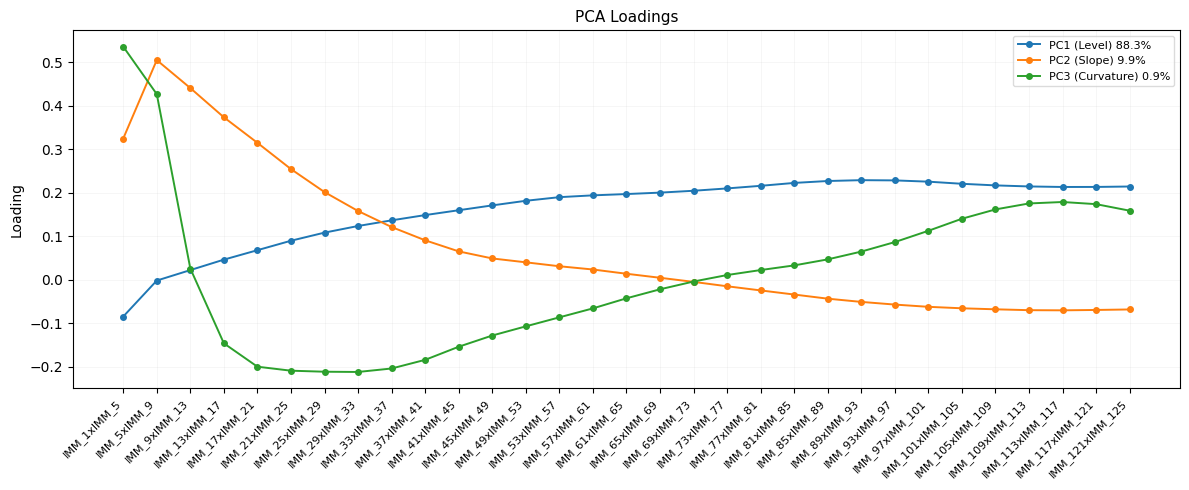

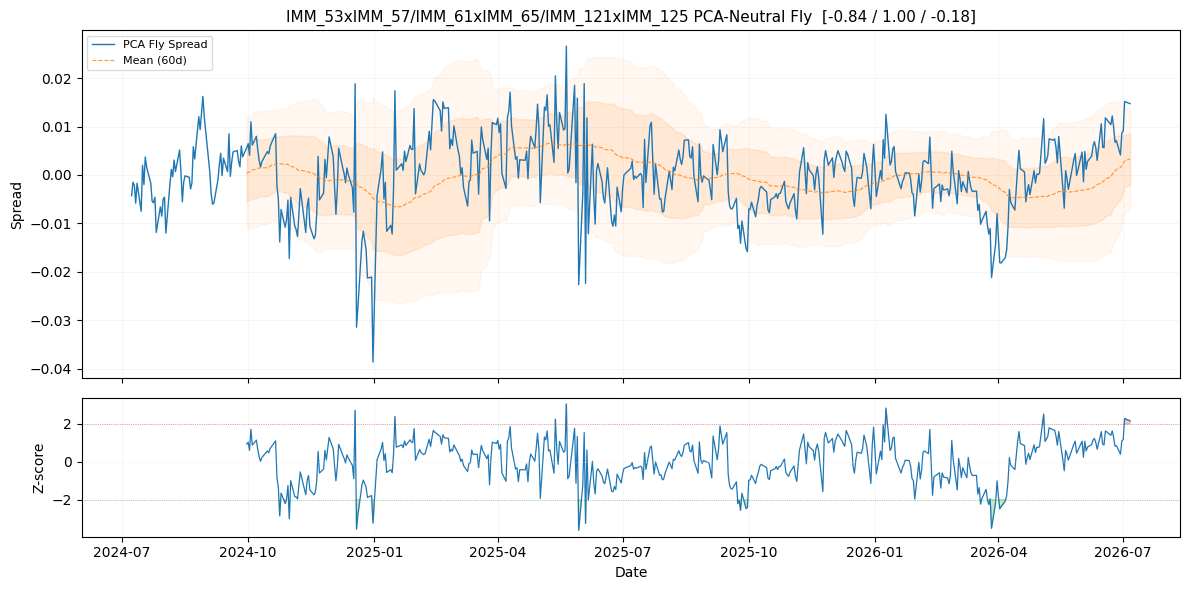

In [10]:
from RVUtils.pca_rv_plots import (
    plot_residual_snapshot, plot_residual_range, plot_pca_vs_actual,
    plot_fly_scanner, plot_fly_timeseries, plot_loadings,
)

# --- Residual snapshot bar chart (CS "PCA Unleashed" Exhibit 19) ---
fig, ax = plot_residual_snapshot(df_s, on="levels", n_factors=2, zscore_window=60)
plt.show()

# --- Residual range (ING Fig 1: min/p5/median/p95/max + current) ---
fig, ax = plot_residual_range(df_s, on="levels", n_factors=2, range_window=200)
plt.show()

# --- Actual vs PCA fair value curve ---
fig, ax = plot_pca_vs_actual(df_s, on="levels", n_factors=2)
plt.show()

# --- Fly scanner: top dislocated flies ---
fig, ax = plot_fly_scanner(df_s, on="levels", n_factors=2, zscore_window=60, top_n=12)
plt.show()

# --- PCA loadings ---
fig, ax = plot_loadings(df_s, on="levels", n_factors=2)
plt.show()

# --- Deep dive: timeseries for top-ranked fly from screen_flies ---
if not sf.empty:
    top = sf.iloc[0]
    fig, axes = plot_fly_timeseries(
        df_s, top["short"], top["body"], top["long"],
        on="levels", n_factors=3, zscore_window=60,
    )
    plt.show()

In [6]:
fig, axes = plot_fly_timeseries(
	df_s, "1y", "1y1y", "2y1y",
	on="levels", n_factors=3, zscore_window=60,
)
plt.show()

KeyError: '1y'